Leemos los datos mensuales de la estación de Alosno (Huelva) del 1 de enero de 2020 al 31 de diciembre de 2024


In [5]:
import pandas as pd
data=pd.read_csv("DatosMensuales_2020_2024.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   e           63 non-null     float64
 1   fecha       65 non-null     object 
 2   hr          59 non-null     float64
 3   indicativo  65 non-null     object 
 4   np_001      59 non-null     float64
 5   np_010      59 non-null     float64
 6   np_100      59 non-null     float64
 7   np_300      59 non-null     float64
 8   nt_00       61 non-null     float64
 9   nt_30       61 non-null     float64
 10  nw_55       61 non-null     float64
 11  nw_91       61 non-null     float64
 12  p_max       59 non-null     object 
 13  p_mes       59 non-null     float64
 14  ta_max      61 non-null     object 
 15  ta_min      61 non-null     object 
 16  ti_max      61 non-null     float64
 17  tm_max      61 non-null     float64
 18  tm_mes      61 non-null     float64
 19  tm_min      61 non-null     flo

In [7]:
# Convertir columnas object a datetime cuando tenga sentido
obj_cols = data.select_dtypes(include='object').columns

# Asegurarse de convertir 'fecha' (si existe) definitivamente
if 'fecha' in obj_cols:
    data['fecha'] = pd.to_datetime(data['fecha'], errors='coerce', dayfirst=True, infer_datetime_format=True)

# Intentar convertir otras columnas object si la mayoría de sus valores se parsean como fecha
for col in obj_cols:
    if col == 'fecha':
        continue
    parsed = pd.to_datetime(data[col], errors='coerce', dayfirst=True, infer_datetime_format=True)
    parsed_ok = parsed.notna().sum()
    orig_nonnull = data[col].notna().sum()
    # Umbral: al menos el 50% de los valores no nulos parseados correctamente
    if orig_nonnull > 0 and parsed_ok >= 0.5 * orig_nonnull:
        data[col] = parsed
        print(f"Convertido a datetime: {col} ({parsed_ok}/{orig_nonnull} parseados)")
    else:
        print(f"Omitido (no parece fecha): {col} ({parsed_ok}/{orig_nonnull} parseados)")

data.info()

Omitido (no parece fecha): indicativo (0/65 parseados)
Omitido (no parece fecha): p_max (0/59 parseados)
Omitido (no parece fecha): ta_max (0/61 parseados)
Omitido (no parece fecha): ta_min (0/61 parseados)
Omitido (no parece fecha): w_racha (0/61 parseados)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   e           63 non-null     float64       
 1   fecha       60 non-null     datetime64[ns]
 2   hr          59 non-null     float64       
 3   indicativo  65 non-null     object        
 4   np_001      59 non-null     float64       
 5   np_010      59 non-null     float64       
 6   np_100      59 non-null     float64       
 7   np_300      59 non-null     float64       
 8   nt_00       61 non-null     float64       
 9   nt_30       61 non-null     float64       
 10  nw_55       61 non-null     float64       
 11  nw_91    

C:\Users\Carlos Delay\AppData\Local\Temp\ipykernel_16124\1409133374.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(data[col], errors='coerce', dayfirst=True, infer_datetime_format=True)
C:\Users\Carlos Delay\AppData\Local\Temp\ipykernel_16124\1409133374.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(data[col], errors='coerce', dayfirst=True, infer_datetime_format=True)
C:\Users\Carlos Delay\AppData\Local\Temp\ipykernel_16124\1409133374.py:12: UserWarning: Could not infer format, so each element wi

In [9]:
data.fecha

0    2020-01-01
1    2020-02-01
2    2020-03-01
3    2020-04-01
4    2020-05-01
        ...    
60   2024-09-01
61   2024-10-01
62   2024-11-01
63   2024-12-01
64          NaT
Name: fecha, Length: 65, dtype: datetime64[ns]

<Axes: ylabel='Frequency'>

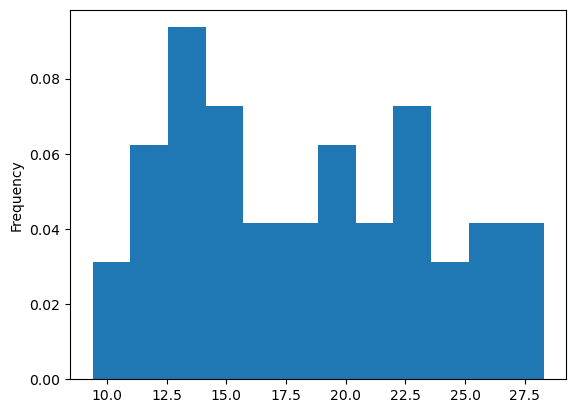

In [4]:
data.tm_mes.plot.hist(density=True, bins=12)

Vamos a intentar buscar correlación entre variables. 
En primer lugar, buscaremos entre temperatura y humedad.
Se observa que los meses más húmedos son diciembre-enero y los más secos junio-julio-agosto.
La mezcla de colores que representa los diferentes años, muestra que el comportamiento ha sido similar.

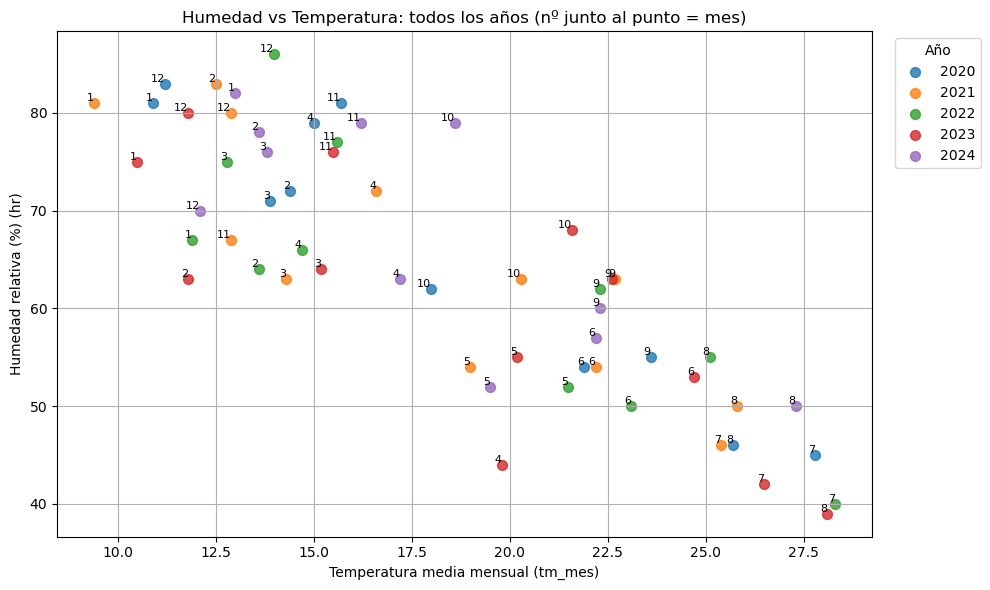

In [10]:
import numpy as np

import matplotlib.pyplot as plt

# Preparar datos (no repetir importaciones/definiciones ya existentes)
df = data.copy()

# Asegurar que temperatura media mensual y humedad son numéricos
df['tm_mes'] = pd.to_numeric(df['tm_mes'], errors='coerce')
df['hr'] = pd.to_numeric(df['hr'], errors='coerce')

# Extraer mes y año (usar 'anio' si existe)
if 'fecha' in df.columns and df['fecha'].notna().any():
    df['month'] = df['fecha'].dt.month
else:
    df['month'] = np.nan

if 'anio' in df.columns:
    df['year'] = df['anio']
else:
    df['year'] = df['fecha'].dt.year

# Filtrar filas válidas
plot_df = df.dropna(subset=['tm_mes', 'hr', 'year', 'month'])

# Gráfico: humedad vs temperatura, un color/serie por año y número del mes junto al punto
fig, ax = plt.subplots(figsize=(10, 6))
years = sorted(plot_df['year'].unique())
cmap = plt.get_cmap('tab10')

for i, y in enumerate(years):
    sub = plot_df[plot_df['year'] == y]
    ax.scatter(sub['tm_mes'], sub['hr'], label=str(y), color=cmap(i % 10), s=50, alpha=0.8)
    # Anotar cada punto con el número de mes
    for _, row in sub.iterrows():
        ax.text(row['tm_mes'], row['hr'], str(int(row['month'])), fontsize=8, ha='right', va='bottom')

ax.set_xlabel('Temperatura media mensual (tm_mes)')
ax.set_ylabel('Humedad relativa (%) (hr)')
ax.set_title('Humedad vs Temperatura: todos los años (nº junto al punto = mes)')
ax.legend(title='Año', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

Especificamos qué significa cada una de las variables que aparecen en los datos ya que carecemos de metadatos.

In [11]:
import pandas as pd

# Cell to inspect and produce an "apparent meaning" + suggested intuitive names for columns in `df`
# Uses existing `df` from the notebook.


suggestions = [
    {"original": "e",
     "suggested": "sunshine_hours_monthly",
     "description": "Horas de sol estimadas por mes (valores mayores en verano, menores en invierno).",
     "confidence": "medium-high"},
    {"original": "fecha",
     "suggested": "date",
     "description": "Fecha del registro (primer día del mes). dtype datetime64[ns].",
     "confidence": "high"},
    {"original": "hr",
     "suggested": "relative_humidity_pct",
     "description": "Humedad relativa media mensual en %.",
     "confidence": "high"},
    {"original": "indicativo",
     "suggested": "station_id",
     "description": "Código/identificador de la estación (texto).",
     "confidence": "high"},
    {"original": "np_001",
     "suggested": "n_days_precip_>=0.1mm",
     "description": "Número de días con precipitación >= ~0.1 mm (conteo mensual).",
     "confidence": "medium"},
    {"original": "np_010",
     "suggested": "n_days_precip_>=1mm",
     "description": "Número de días con precipitación >= ~1 mm (conteo mensual).",
     "confidence": "medium"},
    {"original": "np_100",
     "suggested": "n_days_precip_>=10mm",
     "description": "Número de días con precipitación >= ~10 mm (conteo mensual).",
     "confidence": "medium"},
    {"original": "np_300",
     "suggested": "n_days_precip_>=30mm",
     "description": "Número de días con precipitación >= ~30 mm (conteo mensual).",
     "confidence": "medium"},
    {"original": "nt_00",
     "suggested": "n_days_tmin_<=0C",
     "description": "Número de días con temperatura mínima <= 0 °C (días de helada).",
     "confidence": "high"},
    {"original": "nt_30",
     "suggested": "n_days_tmax_>=30C",
     "description": "Número de días con temperatura máxima >= 30 °C (días calurosos).",
     "confidence": "high"},
    {"original": "nw_55",
     "suggested": "n_days_wind_>=5.5ms",
     "description": "Número de días con viento medio/ráfaga por encima de ~5.5 m/s (umbral aproximado).",
     "confidence": "medium"},
    {"original": "nw_91",
     "suggested": "n_days_wind_>=9.1ms",
     "description": "Número de días con viento medio/ráfaga por encima de ~9.1 m/s (umbral aproximado).",
     "confidence": "medium"},
    {"original": "p_max",
     "suggested": "precip_max_daily_mm(day)",
     "description": "Precipitación máxima diaria del mes en formato 'valor(día)' (ej. '24.4(15)').",
     "confidence": "high"},
    {"original": "p_mes",
     "suggested": "precip_total_month_mm",
     "description": "Precipitación total del mes en mm.",
     "confidence": "high"},
    {"original": "ta_max",
     "suggested": "air_temp_max_degC(day)",
     "description": "Temperatura máxima absoluta del mes con día entre paréntesis (ej. '17.8(17)').",
     "confidence": "high"},
    {"original": "ta_min",
     "suggested": "air_temp_min_degC(day)",
     "description": "Temperatura mínima absoluta del mes con día entre paréntesis.",
     "confidence": "high"},
    {"original": "ti_max",
     "suggested": "temp_inst_max_degC",
     "description": "Estadística de temperatura (posible 'temperatura instantánea máxima' o similar). Interpretación incierta.",
     "confidence": "low"},
    {"original": "tm_max",
     "suggested": "temp_mean_of_daily_max_degC",
     "description": "Media de las temperaturas máximas diarias del mes (interpretación probable).",
     "confidence": "medium"},
    {"original": "tm_mes",
     "suggested": "temp_mean_month_degC",
     "description": "Temperatura media mensual (promedio del mes).",
     "confidence": "high"},
    {"original": "tm_min",
     "suggested": "temp_mean_of_daily_min_degC",
     "description": "Media de las temperaturas mínimas diarias del mes (interpretación probable).",
     "confidence": "medium"},
    {"original": "ts_min",
     "suggested": "soil_temp_min_degC",
     "description": "Temperatura mínima del suelo (o sensor de suelo) mensual (interpretación probable).",
     "confidence": "medium"},
    {"original": "w_med",
     "suggested": "wind_mean_speed",
     "description": "Velocidad media del viento mensual (unidad no explícita: m/s o km/h).",
     "confidence": "medium"},
    {"original": "w_racha",
     "suggested": "wind_gust_info",
     "description": "Información de racha máxima en formato tipo 'dir/speed(day)' o 'speed/dir(day)'. Contiene dirección/velocidad/día entre paréntesis.",
     "confidence": "medium"},
    {"original": "w_rec",
     "suggested": "wind_gust_dir_deg",
     "description": "Dirección (grados) asociada a la racha máxima o viento representativo (valores ~0-360).",
     "confidence": "medium"},
    {"original": "anio",
     "suggested": "year_from_source",
     "description": "Año del registro (entero). Redundante con 'fecha' y 'year'.",
     "confidence": "high"},
    {"original": "n_cub",
     "suggested": "n_overcast_days",
     "description": "Número de días con cielo cubierto/ muy nublado (conteo mensual).",
     "confidence": "medium"},
    {"original": "n_des",
     "suggested": "n_clear_days",
     "description": "Número de días despejados (conteo mensual).",
     "confidence": "medium"},
    {"original": "n_nub",
     "suggested": "n_partly_cloudy_days",
     "description": "Número de días parcialmente nubosos (conteo mensual).",
     "confidence": "medium"},
    {"original": "month",
     "suggested": "month_num",
     "description": "Número de mes (1-12). Redundante con 'fecha'.",
     "confidence": "high"},
    {"original": "year",
     "suggested": "year",
     "description": "Año del registro (entero). Redundante con 'fecha' y 'anio'.",
     "confidence": "high"}
]

mapping_df = pd.DataFrame(suggestions)
# show compact table
pd.set_option("display.max_colwidth", 120)
mapping_df[["original", "suggested", "description", "confidence"]]

,original,suggested,description,confidence
0,e,sunshine_hours_monthly,"Horas de sol estimadas por mes (valores mayores en verano, menores en invierno).",medium-high
1,fecha,date,Fecha del registro (primer día del mes). dtype datetime64[ns].,high
2,hr,relative_humidity_pct,Humedad relativa media mensual en %.,high
3,indicativo,station_id,Código/identificador de la estación (texto).,high
4,np_001,n_days_precip_>=0.1mm,Número de días con precipitación >= ~0.1 mm (conteo mensual).,medium
5,np_010,n_days_precip_>=1mm,Número de días con precipitación >= ~1 mm (conteo mensual).,medium
6,np_100,n_days_precip_>=10mm,Número de días con precipitación >= ~10 mm (conteo mensual).,medium
7,np_300,n_days_precip_>=30mm,Número de días con precipitación >= ~30 mm (conteo mensual).,medium
8,nt_00,n_days_tmin_<=0C,Número de días con temperatura mínima <= 0 °C (días de helada).,high
9,nt_30,n_days_tmax_>=30C,Número de días con temperatura máxima >= 30 °C (días calurosos).,high


In [ ]:
# Mostrar la columna 'nt_00' del DataFrame existente (nº de días con tmin <= 0°C)
print(data['nt_00'])

# Asegurarse de que existen las columnas 'month' y 'year' antes de seleccionarlas
if 'month' not in data.columns or 'year' not in data.columns:
	# Preferir obtener mes/año desde 'fecha' si es datetime
	if 'fecha' in data.columns and pd.api.types.is_datetime64_any_dtype(data['fecha']):
		data['month'] = data['fecha'].dt.month
		data['year'] = data['fecha'].dt.year
	else:
		# Si no hay 'fecha', usar 'anio' si existe
		if 'anio' in data.columns:
			data['year'] = data['anio']
		# Si no podemos inferir 'month', crear columna con NA
		if 'month' not in data.columns:
			data['month'] = pd.NA

# Mostrar filas/meses con más de un día de tmin <= 0°C
mask = pd.to_numeric(data['nt_00'], errors='coerce') > 1
data.loc[mask, ['fecha', 'nt_00', 'month', 'year']]

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
60    0.0
61    0.0
62    0.0
63    0.0
64    NaN
Name: nt_00, Length: 65, dtype: float64


,fecha,nt_00,month,year
13,2021-01-01,3.0,1.0,2021.0
25,NaT,3.0,NaN,NaN


: 